# Import Required Libraries
Imports essential libraries for data manipulation, preprocessing, modeling, evaluation, and visualization to build a professional fraud detection pipeline.

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, precision_recall_curve, roc_curve, confusion_matrix
from imblearn.over_sampling import SMOTE
import time

%matplotlib inline

# Load and Explore the Dataset
Loads the Credit Card Fraud Detection dataset (284,807 rows) and performs exploratory data analysis (EDA) to understand its structure and imbalance.

In [50]:
start_time = time.time()

df = pd.read_csv('creditcard.csv')
print("Dataset Shape:", df.shape)

print("\nDataset Info:")
print(df.info())

Dataset Shape: (284807, 31)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20  

In [51]:
print("\nClass Distribution (%):")
print(df['Class'].value_counts(normalize=True) * 100)


Class Distribution (%):
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [52]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


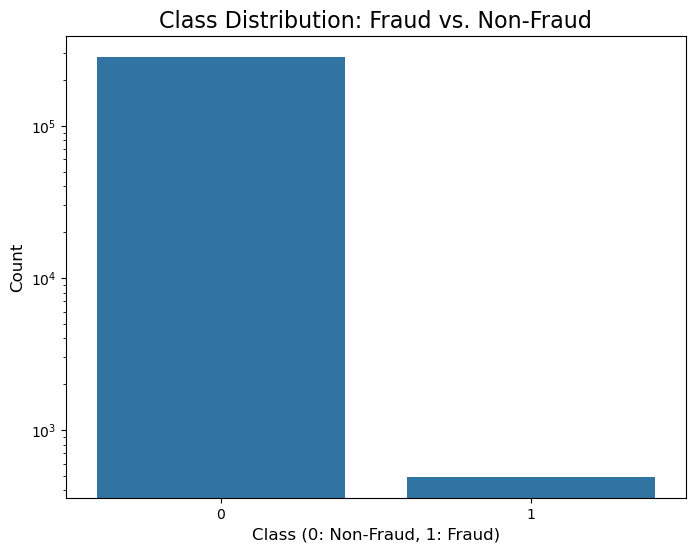

In [53]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Class', data=df)
plt.title('Class Distribution: Fraud vs. Non-Fraud', fontsize=16)
plt.xlabel('Class (0: Non-Fraud, 1: Fraud)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.yscale('log')  # Log scale for visibility
plt.show()

In [ ]:
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15   
std    1.380247e+00  

# Preprocess and Feature Engineering
Scales features using StandardScaler, adds an engineered feature (Amount-to-Time ratio), and applies SMOTE to balance the training set, addressing the 0.172% fraud imbalance.

In [55]:
df['Amount_Time_Ratio'] = df['Amount'] / (df['Time'] + 1)   # WE DON'T WANT TO DIVIDE BY ZERO (just to avoid it)

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Test Set Fraud Cases: {y_test.sum()}")


Test Set Fraud Cases: 98


In [56]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print(f"SMOTE-Balanced Training Set Shape: {X_train_smote.shape}")

SMOTE-Balanced Training Set Shape: (454902, 31)


# Visualize Key Features
Plots distributions of 'Time', 'Amount', and 'Amount_Time_Ratio' to compare fraud vs. non-fraud patterns, showcasing data exploration skills.

In [57]:
X_train_smote_df = pd.DataFrame(X_train_smote, columns=X.columns)
y_train_smote_df = pd.Series(y_train_smote, name='Class')

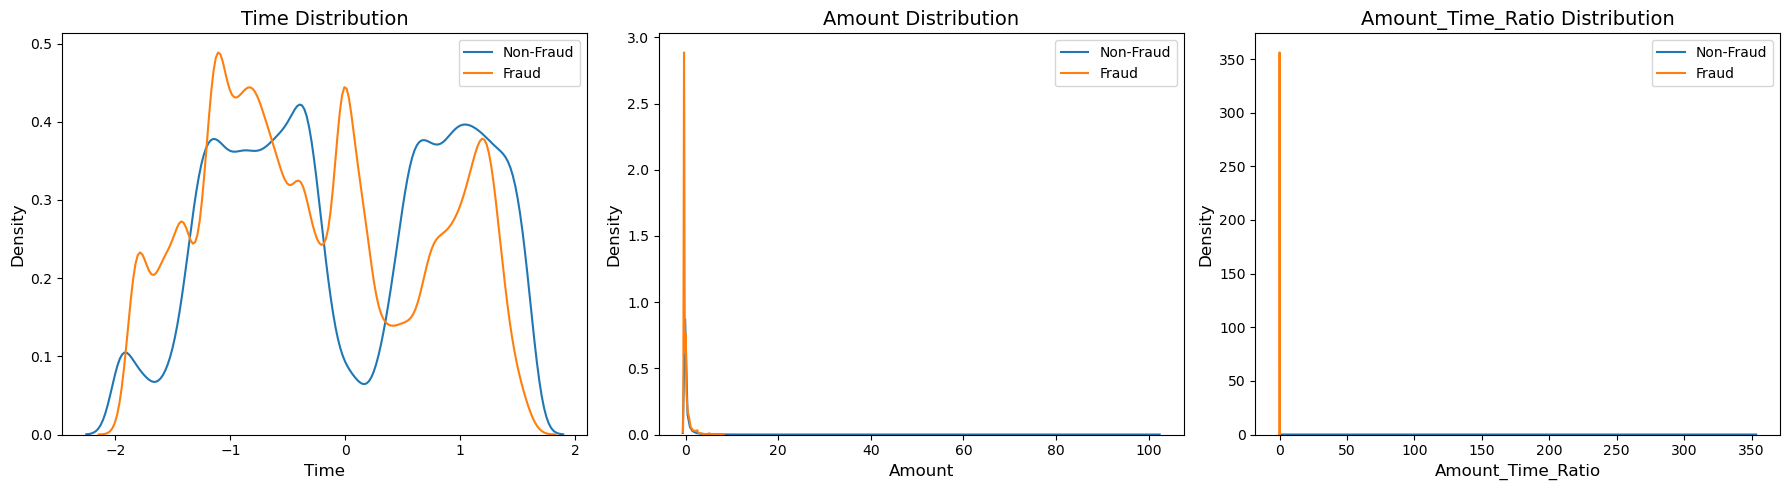

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feature in zip(axes, ['Time', 'Amount', 'Amount_Time_Ratio']):
    sns.kdeplot(data=X_train_smote_df[y_train_smote_df == 0], x=feature, label='Non-Fraud', ax=ax)
    sns.kdeplot(data=X_train_smote_df[y_train_smote_df == 1], x=feature, label='Fraud', ax=ax)
    ax.set_title(f'{feature} Distribution', fontsize=14)
    ax.set_xlabel(feature, fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.legend()
plt.tight_layout()
plt.show()

# Train the Logistic Regression Model
Trains a Logistic Regression model with balanced class weights on the SMOTE-balanced training data for fraud detection.

In [65]:
log_reg = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
log_reg.fit(X_train_smote, y_train_smote)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# Generate Predictions and Scores
Computes decision scores on the test set and applies the pre-determined 80% recall threshold (20.2840) to generate predictions.

In [66]:
y_scores = log_reg.decision_function(X_test_scaled)

optimal_threshold = 20.2840
y_pred = (y_scores > optimal_threshold).astype(int)

# Evaluate Model and Visualize Performance
Evaluates the model at the 80% recall threshold (20.2840), computes ROC AUC, and visualizes the ROC and Precision-Recall curves for a professional assessment.

In [67]:
y_scores = log_reg.decision_function(X_test_scaled)

print('\nLogistic Regression Test Set Performance:')
print(f'ROC AUC Score: {roc_auc_score(y_test, y_scores):.4f}')



Logistic Regression Test Set Performance:
ROC AUC Score: 0.9657


In [68]:
optimal_threshold = 20.2840
test_pred = (y_scores > optimal_threshold).astype(int)

print("\nWith 80% (~78/98) Recall Threshold:")
print(f'Threshold: {optimal_threshold:.4f}')
print(f'Classification Report:\n{classification_report(y_test, test_pred)}')
print(f'Confusion Matrix:\n{pd.crosstab(y_test, test_pred, rownames=["Actual"], colnames=["Predicted"])}')


With 80% (~78/98) Recall Threshold:
Threshold: 20.2840
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.80      0.81        98

    accuracy                           1.00     56962
   macro avg       0.91      0.90      0.91     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
Predicted      0   1
Actual              
0          56848  16
1             20  78


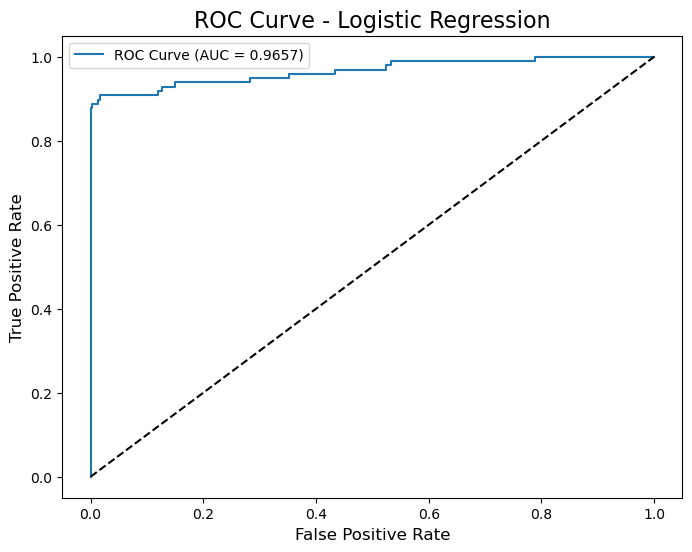

In [69]:
fpr, tpr, _ = roc_curve(y_test, y_scores)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_scores):.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve - Logistic Regression', fontsize=16)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend()
plt.show()

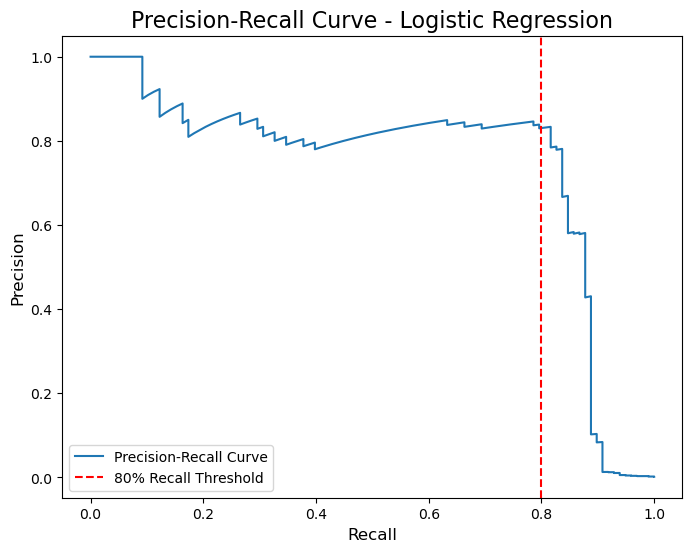

In [70]:
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label='Precision-Recall Curve')
plt.axvline(x=0.80, color='r', linestyle='--', label='80% Recall Threshold')
plt.title('Precision-Recall Curve - Logistic Regression', fontsize=16)
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.legend()
plt.show()

# Visualize Confusion Matrix
Creates a heatmap of the confusion matrix for a clear, professional presentation of model performance at 80% recall.

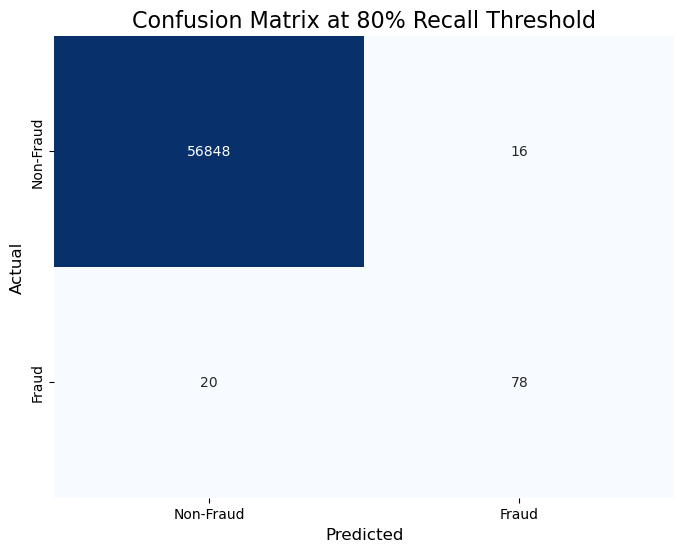

In [71]:
# Confusion matrix heatmap
cm = confusion_matrix(y_test, test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])
plt.title('Confusion Matrix at 80% Recall Threshold', fontsize=16)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()

# Finalize and Report Execution Time
Concludes the analysis with execution time and a summary of the best result for professional documentation.

In [73]:
roc_auc = roc_auc_score(y_test, y_scores)

class_report = classification_report(y_test, y_pred, target_names=['Non-Fraud', 'Fraud'])
cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()
fpr = fp / (fp + tn)

In [74]:
# Print detailed report
print('\nLogistic Regression Performance at 80% Recall Threshold')
print('----------------------------------------------------')
print(f'Threshold: {optimal_threshold:.4f}')
print(f'ROC AUC Score: {roc_auc:.4f}')
print('\nClassification Report:')
print(class_report)
print('Confusion Matrix:')
print(pd.DataFrame(cm, index=['Actual Non-Fraud', 'Actual Fraud'], 
                   columns=['Predicted Non-Fraud', 'Predicted Fraud']))
print('\nKey Metrics Breakdown:')
print(f'True Positives (Fraud Detected): {tp}')
print(f'False Negatives (Fraud Missed): {fn}')
print(f'False Positives (Non-Fraud Flagged): {fp}')
print(f'True Negatives (Non-Fraud Correct): {tn}')
print(f'False Positive Rate: {fpr:.4%}')
print('\nMetric Definitions:')
print('- ROC AUC: Measures overall ranking ability (1 = perfect, 0.5 = random)')
print('- Precision: Proportion of fraud predictions that are correct')
print('- Recall: Proportion of actual fraud cases detected')
print('- F1-Score: Harmonic mean of precision and recall')
print('- FPR: Proportion of non-fraud cases incorrectly flagged')


Logistic Regression Performance at 80% Recall Threshold
----------------------------------------------------
Threshold: 20.2840
ROC AUC Score: 0.9657

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     56864
       Fraud       0.83      0.80      0.81        98

    accuracy                           1.00     56962
   macro avg       0.91      0.90      0.91     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
                  Predicted Non-Fraud  Predicted Fraud
Actual Non-Fraud                56848               16
Actual Fraud                       20               78

Key Metrics Breakdown:
True Positives (Fraud Detected): 78
False Negatives (Fraud Missed): 20
False Positives (Non-Fraud Flagged): 16
True Negatives (Non-Fraud Correct): 56848
False Positive Rate: 0.0281%

Metric Definitions:
- ROC AUC: Measures overall ranking ability (1 = perfect, 0.5 = random)
- Precision: Pro

# Deploy the Model with Flask API
Created a Flask application to serve the trained model as a REST API. Accepts transaction data via POST requests and returns fraud predictions. Check out app.py file (not yet made)

In [75]:
import joblib
joblib.dump(log_reg, 'fraud_detection_model.pkl')

['fraud_detection_model.pkl']

In [76]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']